# CAN 메시지 분석

## DATASET 로드
---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#데이터셋 로드
df = pd.read_csv('Pre_train_D_0.csv')
df_can = df.copy()
basetime = df_can['Timestamp'][0]
print(basetime)
#Timestamp offset을 0으로 조정
df_can['Timestamp']= df_can['Timestamp'] - basetime
print(df_can.shape)
#데이터 확인
df_can.head(20)

1597707827.052591
(179346, 5)


,Timestamp,Arbitration_ID,DLC,Data,Class
0,0.000000,260,8,06 25 05 30 FF CF 71 55,Normal
1,0.001389,329,8,4A C5 7E 8C 31 2D 01 10,Normal
2,0.002079,38D,8,00 00 49 00 90 7F FE 01,Normal
3,0.002313,420,8,50 1E 00 C8 FC 4F 6A 00,Normal
4,0.002549,421,8,FE 07 00 FF E3 7F 00 52,Normal
5,0.002787,153,8,20 80 10 FF 00 FF A0 4E,Normal
6,0.003024,220,8,12 24 7C 00 00 6D 10 F6,Normal
7,0.003262,340,8,00 00 00 24 36 01 25 30,Normal
8,0.003504,389,8,00 00 00 20 00 00 C2 00,Normal
9,0.003747,47F,8,00 EC FF FA 00 78 00 36,Normal


### CAN ID별 분포량 확인
---


In [2]:
df_can['Arbitration_ID'].value_counts().head(40)

Arbitration_ID
260    7466
153    7466
220    7466
251    7465
367    7465
366    7465
356    7465
164    7465
2B0    7465
368    7465
340    7465
329    7465
130    7461
140    7461
391    3734
387    3733
453    3733
4F1    3733
394    3733
470    3733
381    3733
421    3733
420    3733
38D    3733
47F    3733
389    3732
386    3732
492    1493
490    1493
58B    1493
48A    1493
436    1493
485    1493
484    1067
50C     747
541     747
479     747
500     746
495     746
53E     746
Name: count, dtype: int64

Index(['260', '153', '220', '251', '367', '366', '356', '164', '2B0', '368',
       '340', '329', '130', '140', '391', '387', '453', '4F1', '394', '470',
       '381', '421', '420', '38D', '47F', '389', '386', '492', '490', '58B',
       '48A', '436', '485', '484', '50C', '541', '479', '500', '495', '53E',
       '42D', '520', '507', '568', '52A', '4CB', '4C9', '544', '553', '48C',
       '5CD', '593', '53F', '4A9', '5A6', '53B', '44E', '50E', '412', '410',
       '559', '50A', '483', '572', '49F', '4A7', '4A2', '563', '5B0', '043',
       '5BE', '07F', '57F'],
      dtype='object', name='Arbitration_ID')


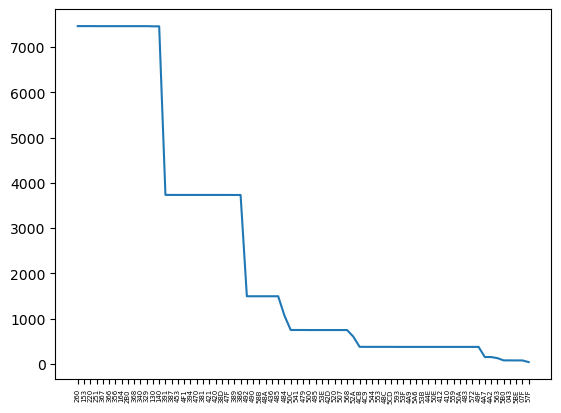

In [3]:
can_id_stats = df_can['Arbitration_ID'].value_counts()

IDs = can_id_stats.index
print(IDs)
values = can_id_stats.values

plt.plot(IDs, values)  # Corrected line
plt.xticks(rotation='vertical', fontsize=5)  # Rotating x-axis labels to be vertical
plt.show()

### CAN ID 별로 메시지 발생 빈도를 확인하기 위해 TimeDelta 계산
---


In [7]:
# Assuming df_can is your DataFrame and it's already defined
can_id_260 = df_can[df_can['Arbitration_ID'] == '260'].reset_index(drop=True)
can_id_260['TimeDelta'] = ((can_id_260['Timestamp'].diff().fillna(0.01)))

can_id_260

,Timestamp,Arbitration_ID,DLC,Data,Class,TimeDelta
0,0.000000,260,8,06 25 05 30 FF CF 71 55,Normal,0.010000
1,0.011067,260,8,06 25 05 30 FF CF 71 64,Normal,0.011067
2,0.020065,260,8,06 25 05 30 FF CF 6F 76,Normal,0.008998
3,0.030849,260,8,06 25 05 30 FF CF 6F 49,Normal,0.010784
4,0.041443,260,8,06 25 05 30 FF CF 6B 5C,Normal,0.010594
...,...,...,...,...,...,...
7461,74.614305,260,8,06 39 1A 30 FF D0 A1 64,Normal,0.009837
7462,74.624354,260,8,06 39 1A 30 FF D0 9F 76,Normal,0.010049
7463,74.634543,260,8,06 39 1A 30 FF D0 9F 49,Normal,0.010189
7464,74.645164,260,8,06 39 1A 30 FF D1 A1 54,Normal,0.010621


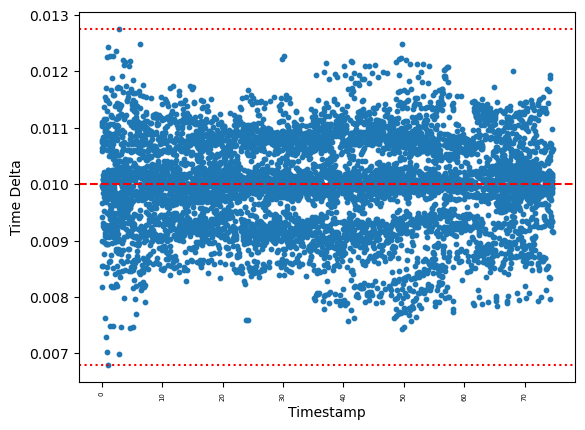

In [223]:
timestamp = can_id_260['Timestamp'].iloc[:-1]
values = can_id_260['TimeDelta'].iloc[:-1]

# Drawing a red dashed line at y=0.006
plt.axhline(y=values.min(), color='r', linestyle=':')
plt.axhline(y=values.max(), color='r', linestyle=':')
plt.axhline(y=values.mean(), color='r', linestyle='--')
plt.scatter(timestamp, values, s=10)  # Scatter plot
plt.xticks(rotation='vertical', fontsize=5)  # Rotating x-axis labels
# Adding labels to the axes
plt.xlabel('Timestamp')
plt.ylabel('Time Delta')
plt.show()

In [233]:
print('Min : ', round(values.min(),4))
print('Max : ', round(values.max(),4))
print('Avg : ', round(values.mean(),4))

Min :  0.0068
Max :  0.0128
Avg :  0.01


### CAN 메시지 그룹별 시계열 분포
---

0      0.499776
1      0.500422
2      0.499572
3      0.500262
4      0.499886
         ...   
143    0.500553
144    0.500226
145    0.499971
146    0.500244
147    0.499806
Name: TimeDelta, Length: 148, dtype: float64


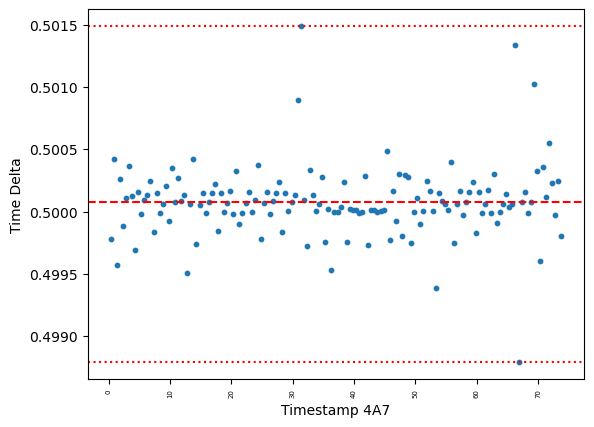

In [388]:
# Assuming df_can is your DataFrame and it's already defined
#1그룹(10ms) '260', '153', '220', '251', '367', '366', '356', '164', '2B0', '368','340', '329', '130', '140' 
#2그룹(20ms) '391', '387', '453', '4F1', '394', '470','381', '421', '420', '38D', '47F', '389', '386'
#3그룹(50ms) '492', '490', '58B', '48A', '436', '485'
#4그룹(70ms) '484'
#5그룹(100ms) '50C', '541', '479', '500', '495', '53E', '42D', '520', '507', '568'    
#6그룹(200ms) '52A'
#7그룹(200ms) '4CB', '4C9', '544', '553', '48C', '5CD', '593', '53F', '4A9', '5A6', '53B', '44E', '50E', '412', '410', '559', '50A', '483', '572', '49F'
#8그룹(500~600ms) '4A7', '4A2', '563'
#9그룹(990ms~1000ms) '5B0', '043', '5BE', '07F'
#10그룹(2000ms) '57F'

# 원하는 CAN ID를 설정한다.
str = '4A7'
can_id = df_can[df_can['Arbitration_ID'] == str].reset_index(drop=True)
# Create a new column 'Timestamp1' shifted by 1
can_id['Timestamp1'] = \
            can_id['Timestamp'].shift(-1).fillna(can_id['Timestamp'])
# Calculate the time delta
can_id['TimeDelta'] = can_id['Timestamp1'] - can_id['Timestamp']
can_id

timestamp = can_id['Timestamp'].iloc[:-1]
values = can_id['TimeDelta'].iloc[:-1]
print(values)
plt.axhline(y=values.min(), color='r', linestyle=':')
plt.axhline(y=values.max(), color='r', linestyle=':')
plt.axhline(y=values.mean(), color='r', linestyle='--')
plt.scatter(timestamp, values, s=10)  # Scatter plot
plt.xticks(rotation='vertical', fontsize=5)  # Rotating x-axis labels
# Adding labels to the axes
plt.xlabel('Timestamp ' + str)
plt.ylabel('Time Delta')
plt.show()

### CAN ID 별 DLC 값의 분포 확인
---
정상인 경우 같은 CAN ID에 대해 동일한 DLC 값을 가짐

In [506]:
can_id_stats = df_can['Arbitration_ID'].value_counts()

IDs = can_id_stats.index
        
for str_id in IDs:
    can_id = df_can[df_can['Arbitration_ID'] == str_id].reset_index(drop=True)
    
    # Get the counts of 'DLC' values for the current ID
    vals = can_id['DLC'].value_counts()
    
    for idx, val in zip(vals.index, vals):
        print(f"ID: {str_id}, DLC: {idx}, Count: {val}, Total: {can_id['DLC'].count()}")

ID: 260, DLC: 8, Count: 7466, Total: 7466
ID: 153, DLC: 8, Count: 7466, Total: 7466
ID: 220, DLC: 8, Count: 7466, Total: 7466
ID: 251, DLC: 8, Count: 7465, Total: 7465
ID: 367, DLC: 8, Count: 7465, Total: 7465
ID: 366, DLC: 7, Count: 7465, Total: 7465
ID: 356, DLC: 8, Count: 7465, Total: 7465
ID: 164, DLC: 4, Count: 7465, Total: 7465
ID: 2B0, DLC: 6, Count: 7465, Total: 7465
ID: 368, DLC: 8, Count: 7465, Total: 7465
ID: 340, DLC: 8, Count: 7465, Total: 7465
ID: 329, DLC: 8, Count: 7465, Total: 7465
ID: 130, DLC: 8, Count: 7461, Total: 7461
ID: 140, DLC: 8, Count: 7461, Total: 7461
ID: 391, DLC: 8, Count: 3734, Total: 3734
ID: 387, DLC: 8, Count: 3733, Total: 3733
ID: 453, DLC: 5, Count: 3733, Total: 3733
ID: 4F1, DLC: 4, Count: 3733, Total: 3733
ID: 394, DLC: 8, Count: 3733, Total: 3733
ID: 470, DLC: 8, Count: 3733, Total: 3733
ID: 381, DLC: 8, Count: 3733, Total: 3733
ID: 421, DLC: 8, Count: 3733, Total: 3733
ID: 420, DLC: 8, Count: 3733, Total: 3733
ID: 38D, DLC: 8, Count: 3733, Tota

### CAN ID 366 Engine Control Unit 의 분석
---


In [473]:
str_id = '366'

can_id = df_can[df_can['Arbitration_ID'] == str_id].reset_index(drop=True)
can_id[['Arbitration_ID', 'Data']]

,Arbitration_ID,Data
0,366,26 82 10 25 21 0B 01
1,366,26 86 10 25 21 0B 01
2,366,25 86 10 25 21 0B 01
3,366,25 86 10 25 21 0B 01
4,366,25 8A 10 25 21 0B 01
...,...,...
7460,366,39 72 11 39 1F 08 01
7461,366,39 74 11 39 1F 08 01
7462,366,39 70 11 39 1F 08 01
7463,366,39 76 11 39 1F 08 01


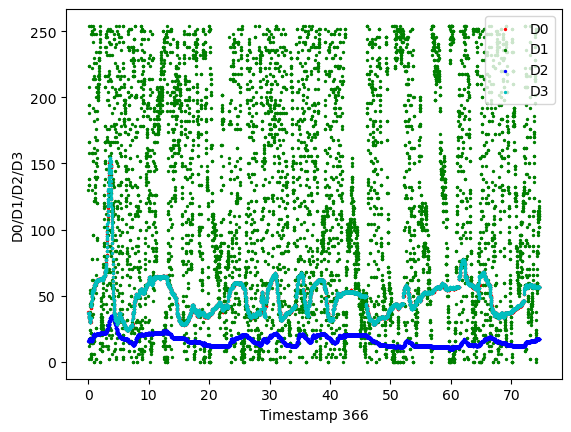

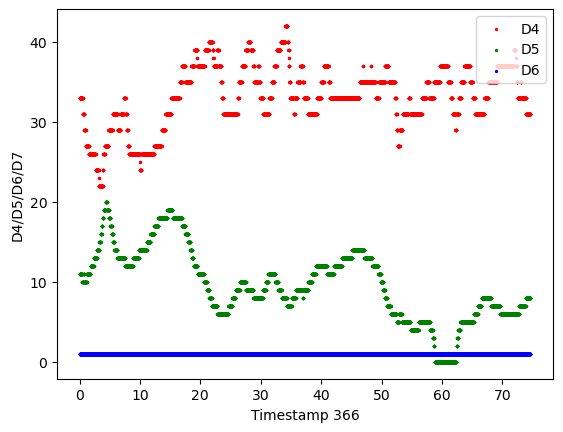

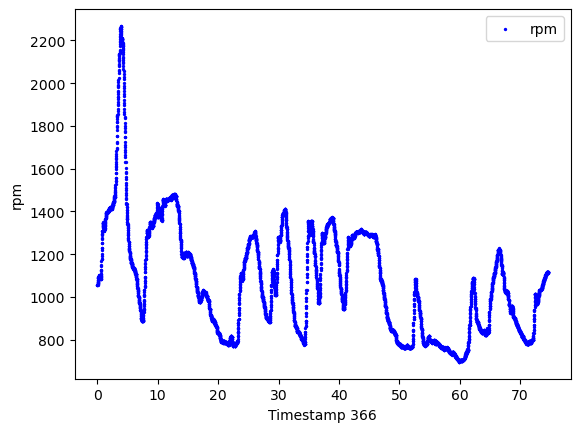

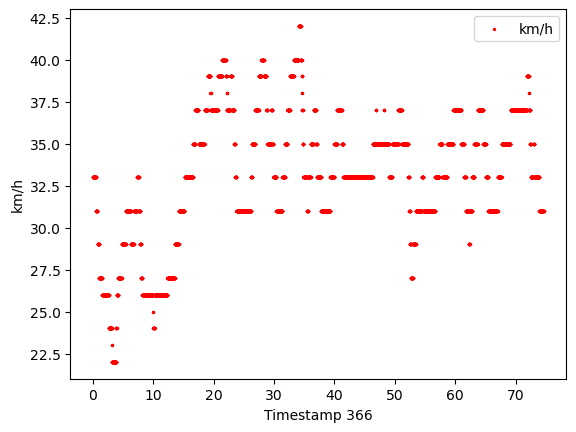

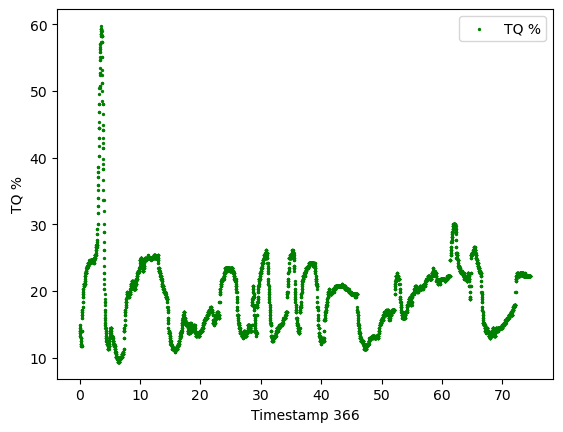

In [484]:
str_id = '366'
DLC = 7

can_id = df_can[df_can['Arbitration_ID'] == str_id].reset_index(drop=True)

data_columns = ['D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7']
colors = ['r','g','b','c','r','g','b','c']
can_id[data_columns[:DLC]] = can_id['Data'].str.split(expand=True).iloc[:, :DLC]
for i in range(DLC):
    can_id[f'D{i}'] = can_id[f'D{i}'].apply(lambda x: int(x, 16))

timestamp = can_id['Timestamp']
for i in range(DLC):
    plt.scatter(timestamp, can_id[f'D{i}'], s=2, color=colors[i], label=f'D{i}')
    if i == 3 or i == (DLC-1):
        plt.xlabel(f'Timestamp {str_id}')
        if i <= 3:
            plt.ylabel('D0/D1/D2/D3')
        else :
            plt.ylabel('D4/D5/D6/D7')
        plt.legend(loc="upper right")
        plt.show()
        
plt.scatter(timestamp, (can_id['D1']+can_id['D2']*256) * 0.25, s=2, color='b', label=f'rpm')
plt.xlabel(f'Timestamp {str_id}')
plt.ylabel('rpm')
plt.legend(loc="upper right")
plt.show()

plt.scatter(timestamp, can_id['D4'], s=2, color='r', label=f'km/h')
plt.xlabel(f'Timestamp {str_id}')
plt.ylabel('km/h')
plt.legend(loc="upper right")
plt.show()

plt.scatter(timestamp, can_id['D0']*0.390625, s=2, color='g', label=f'TQ %')
plt.xlabel(f'Timestamp {str_id}')
plt.ylabel('TQ %')
plt.legend(loc="upper right")
plt.show()

### CAN ID 130 Airbag Control Unit 메시지 분석
---

In [ ]:
str_id = '130'
DLC = 8

can_id = df_can[df_can['Arbitration_ID'] == str_id].reset_index(drop=True)
can_id.loc[1]

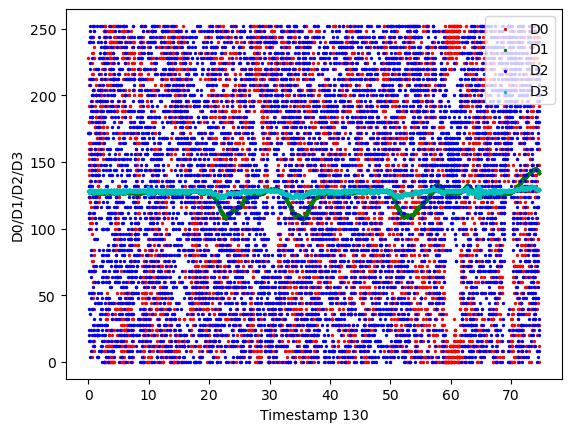

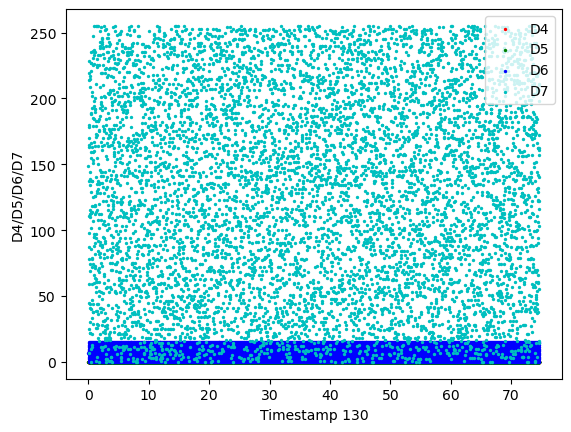

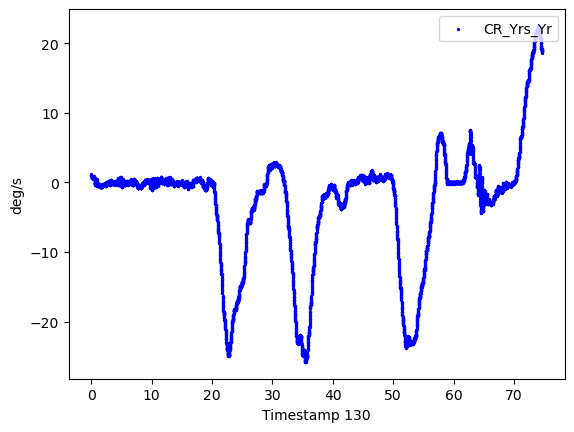

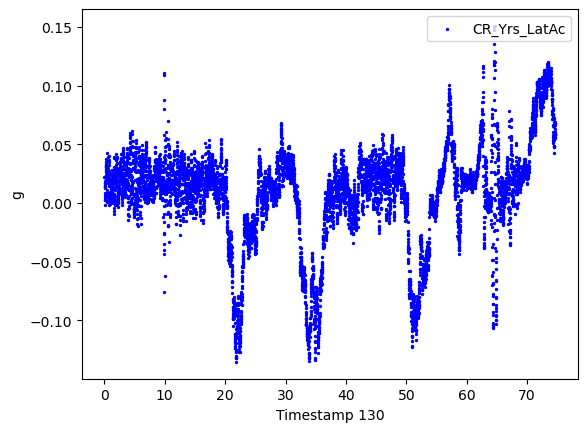

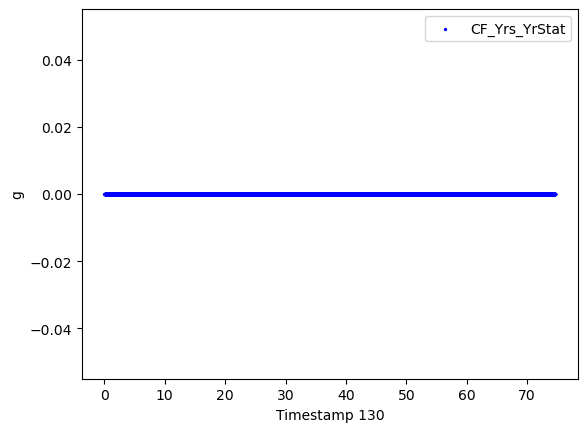

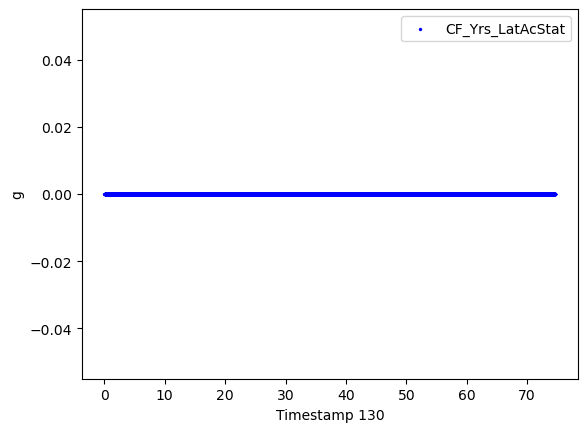

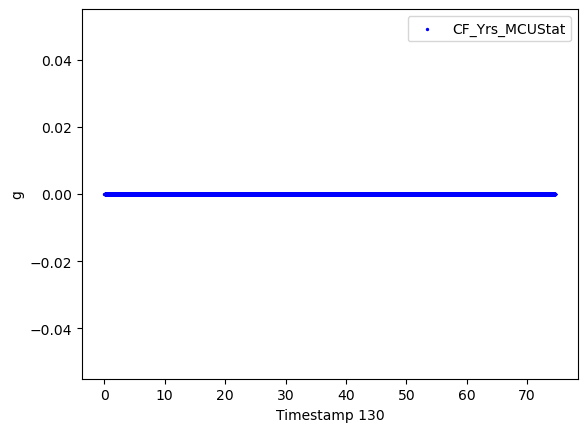

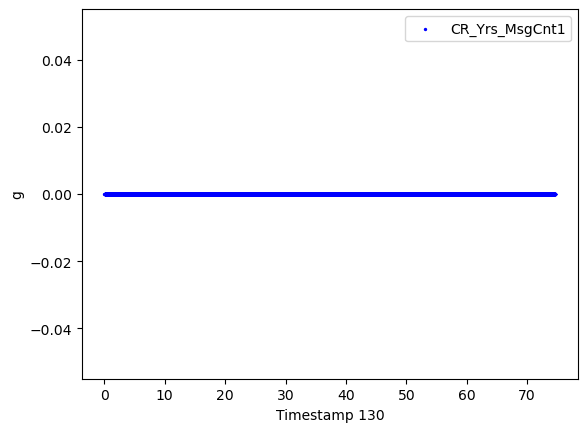

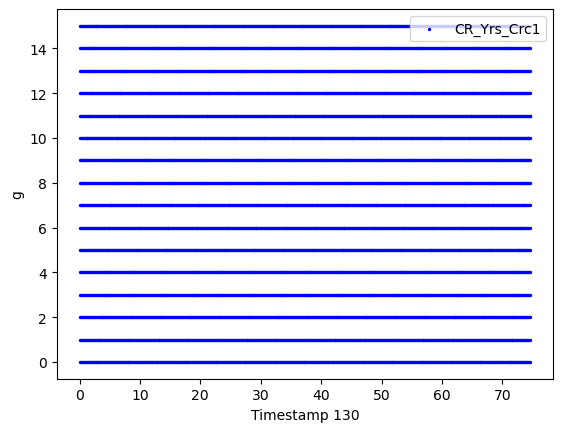

In [507]:
str_id = '130'
DLC = 8

can_id = df_can[df_can['Arbitration_ID'] == str_id].reset_index(drop=True)

data_columns = ['D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7']
colors = ['r','g','b','c','r','g','b','c']
can_id[data_columns[:DLC]] = can_id['Data'].str.split(expand=True).iloc[:, :DLC]
for i in range(DLC):
    can_id[f'D{i}'] = can_id[f'D{i}'].apply(lambda x: int(x, 16))

timestamp = can_id['Timestamp']
for i in range(DLC):
    plt.scatter(timestamp, can_id[f'D{i}'], s=2, color=colors[i], label=f'D{i}')
    if i == 3 or i == (DLC-1):
        plt.xlabel(f'Timestamp {str_id}')
        if i <= 3:
            plt.ylabel('D0/D1/D2/D3')
        else :
            plt.ylabel('D4/D5/D6/D7')
        plt.legend(loc="upper right")
        plt.show()
        
        
plt.scatter(timestamp, (can_id['D0']+can_id['D1']*256) * 0.005-163.84, s=2, color='b', label=f'CR_Yrs_Yr')
plt.xlabel(f'Timestamp {str_id}')
plt.ylabel('deg/s')
plt.legend(loc="upper right")
plt.show()

plt.scatter(timestamp, (can_id['D2']+can_id['D3']*256) * 0.000127465-4.17677312, s=2, color='b', label=f'CR_Yrs_LatAc')
plt.xlabel(f'Timestamp {str_id}')
plt.ylabel('g')
plt.legend(loc="upper right")
plt.show()

plt.scatter(timestamp, (can_id['D4'].apply(lambda x: x>>4)), s=2, color='b', label=f'CF_Yrs_YrStat')
plt.xlabel(f'Timestamp {str_id}')
plt.ylabel('g')
plt.legend(loc="upper right")
plt.show()

plt.scatter(timestamp, (can_id['D4'].apply(lambda x: x&0x0f)), s=2, color='b', label=f'CF_Yrs_LatAcStat')
plt.xlabel(f'Timestamp {str_id}')
plt.ylabel('g')
plt.legend(loc="upper right")
plt.show()

plt.scatter(timestamp, (can_id['D5'].apply(lambda x: x>>4)), s=2, color='b', label=f'CF_Yrs_MCUStat')
plt.xlabel(f'Timestamp {str_id}')
plt.ylabel('g')
plt.legend(loc="upper right")
plt.show()

plt.scatter(timestamp, (can_id['D5'].apply(lambda x: x&0x0f)), s=2, color='b', label=f'CR_Yrs_MsgCnt1')
plt.xlabel(f'Timestamp {str_id}')
plt.ylabel('g')
plt.legend(loc="upper right")
plt.show()

plt.scatter(timestamp, (can_id['D6']), s=2, color='b', label=f'CR_Yrs_Crc1')
plt.xlabel(f'Timestamp {str_id}')
plt.ylabel('g')
plt.legend(loc="upper right")
plt.show()

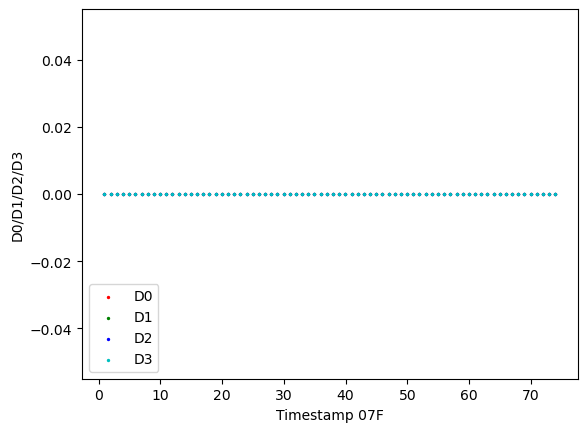

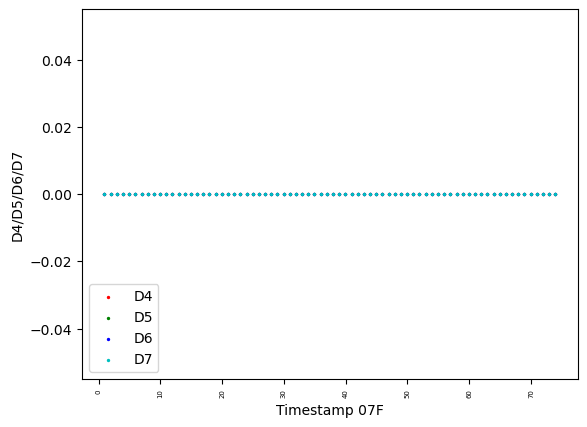

In [461]:


str = '07F'
can_id = df_can[df_can['Arbitration_ID'] == str].reset_index(drop=True)

can_id = pd.DataFrame(can_id)

# Extracting and assigning the first six hex values of each row into separate columns
can_id[['D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7']] = can_id['Data'].str.split(expand=True).iloc[:, :8]
for i in range(8):
    can_id[f'D{i}'] = can_id[f'D{i}'].apply(lambda x: int(x, 16))
can_id.head(40)

timestamp = can_id['Timestamp']
# plt.axhline(y=values.min(), color='r', linestyle=':')
# plt.axhline(y=values.max(), color='r', linestyle=':')
# plt.axhline(y=values.mean(), color='r', linestyle='--')
plt.scatter(timestamp, can_id['D0'], s=2, color='r', label='D0')
plt.scatter(timestamp, can_id['D1'], s=2, color='g', label='D1')
plt.scatter(timestamp, can_id['D2'], s=2, color='b', label='D2')
plt.scatter(timestamp, can_id['D3'], s=2, color='c', label='D3')
# Adding labels to the axes
plt.xlabel('Timestamp ' + str)
plt.ylabel('D0/D1/D2/D3')
plt.legend(loc="lower left")
plt.show()

plt.scatter(timestamp, can_id['D4'], s=2, color='r', label='D4')  # Scatter plot
plt.scatter(timestamp, can_id['D5'], s=2, color='g', label='D5')  # Scatter plot
plt.scatter(timestamp, can_id['D6'], s=2, color='b', label='D6')  # Scatter plot
plt.scatter(timestamp, can_id['D7'], s=2, color='c', label='D7')  # Scatter plot
plt.xticks(rotation='vertical', fontsize=5)  # Rotating x-axis labels
# Adding labels to the axes
plt.xlabel('Timestamp ' + str)
plt.ylabel('D4/D5/D6/D7')
plt.legend(loc="lower left")
plt.show()

